<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [11]:
## Write your code here
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857       24.343232        22.96

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [10]:
## Write your code here
missing_values = df.isna().sum()
print(missing_values.to_string())

ResponseId                            0
MainBranch                            0
Age                                   0
Employment                            0
RemoteWork                        10631
Check                                 0
CodingActivities                  10971
EdLevel                            4653
LearnCode                          4949
LearnCodeOnline                   16200
TechDoc                           24540
YearsCode                          5568
YearsCodePro                      13827
DevType                            5992
OrgSize                           17957
PurchaseInfluence                 18031
BuyNewTool                        20256
BuildvsBuy                        22079
TechEndorse                       21769
Country                            6507
Currency                          18753
CompTotal                         31697
LanguageHaveWorkedWith             5692
LanguageWantToWorkWith             9685
LanguageAdmired                   14565


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



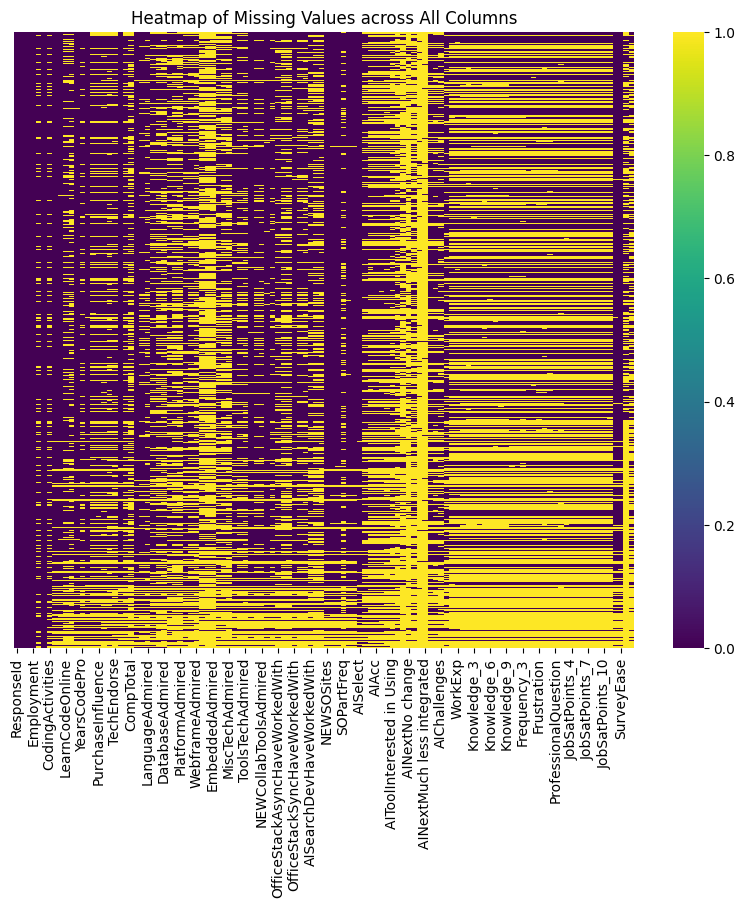

In [12]:
## Write your code here
# 1. Make figure and give it a size
plt.figure(figsize=(10, 8))

# 2. Create the heatmap
# yticklabels=False hides individual row numbers for a cleaner look
# cbar=False removes the color scale bar since it's just True/False
# cmap='viridis' provides a high-contrast color scheme
sns.heatmap(df.isnull(), yticklabels=False, cmap='viridis')

# 3. Add a title and show
plt.title('Heatmap of Missing Values across All Columns')
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [21]:
## Write your code here
employment_missing_values = df['Employment'].isna().sum()
print(f'There are {employment_missing_values} missing Employment values')

remotework_missing_values = df['RemoteWork'].isna().sum()
print(f'There are {remotework_missing_values} missing RemoteWork values')

There are 0 missing Employment values
There are 10631 missing RemoteWork values


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [22]:
## Write your code here

employment_most_freq = df['Employment'].mode()
print(f'The most frequent value in Employment is {employment_most_freq}')

The most frequent value in Employment is 0    Employed, full-time
Name: Employment, dtype: str


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [23]:
## Write your code here

#replace missing values in Employment column with most frequent values
df['Employment'] = df['Employment'].fillna(employment_most_freq)

#check that df is updated with no NA's in Employment column
print(f'Number of missing values for Employemnt: {df['Employment'].isna().sum()}')



Number of missing values for Employemnt: 0


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


/tmp/ipykernel_11720/2028956037.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Employment', order=df['Employment'].value_counts().index, palette='viridis')


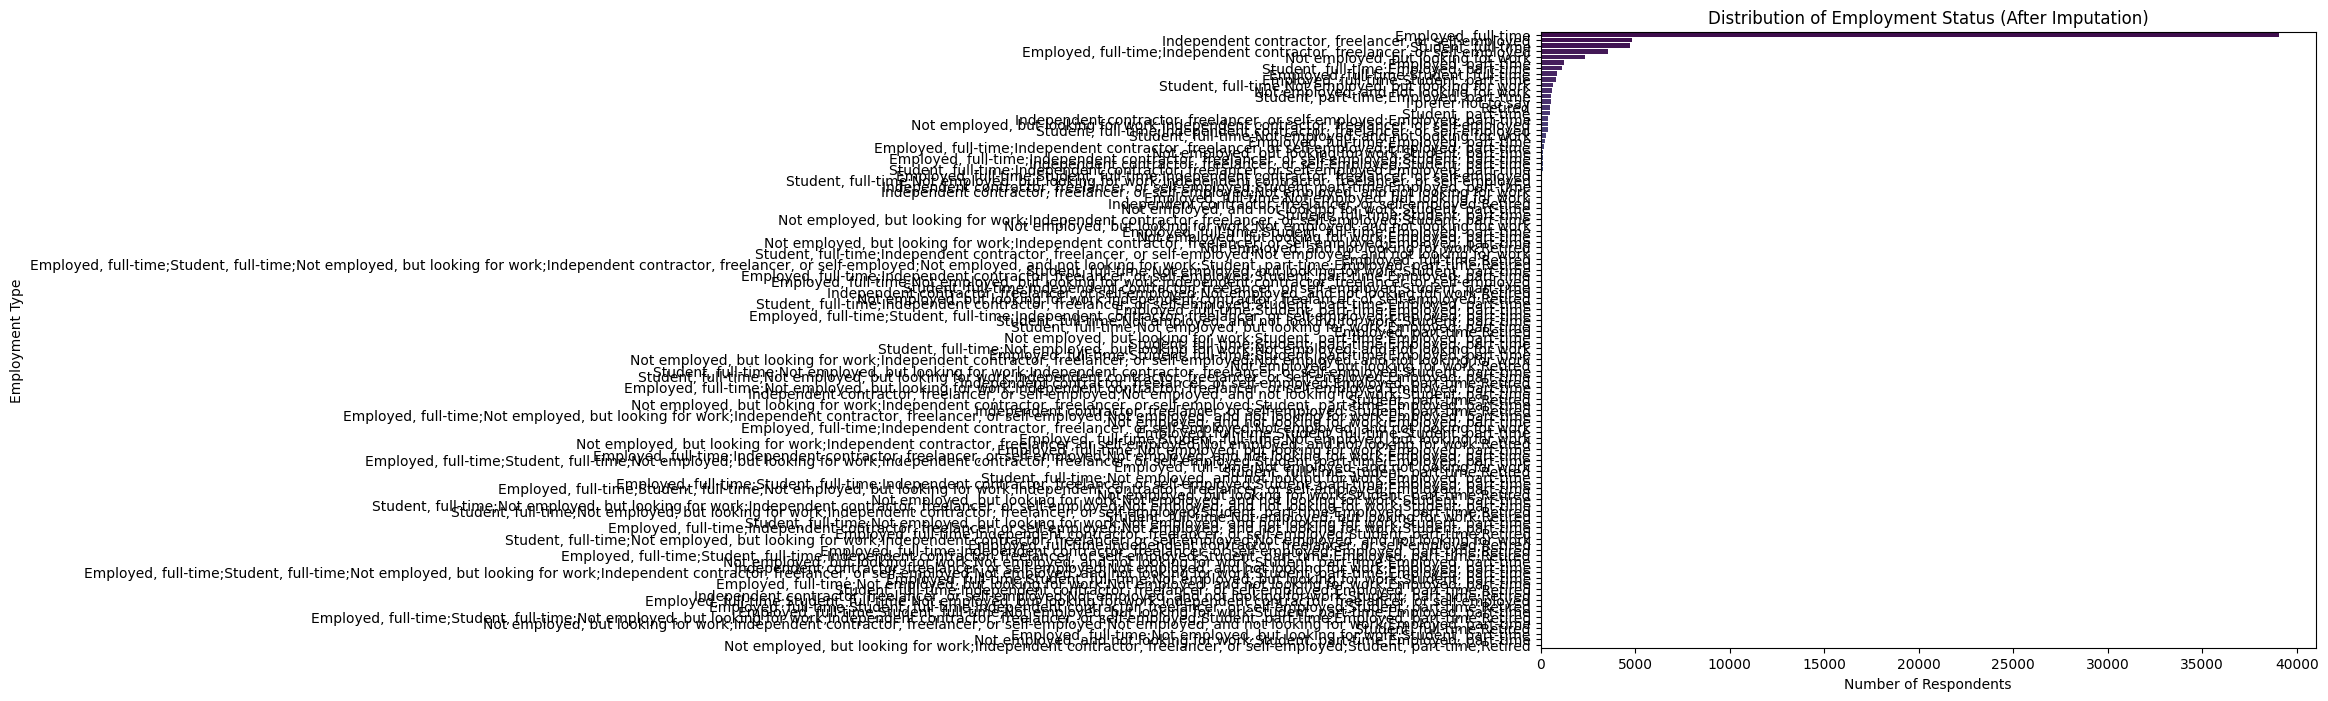

In [25]:
## Write your code here

#Visualize distribution of Employment column after imputation
plt.figure(figsize=(10,8))
# countplot to handle categorical counts
sns.countplot(data=df, y='Employment', order=df['Employment'].value_counts().index, palette='viridis')

plt.title('Distribution of Employment Status (After Imputation)')
plt.xlabel('Number of Respondents')
plt.ylabel('Employment Type')
plt.show()

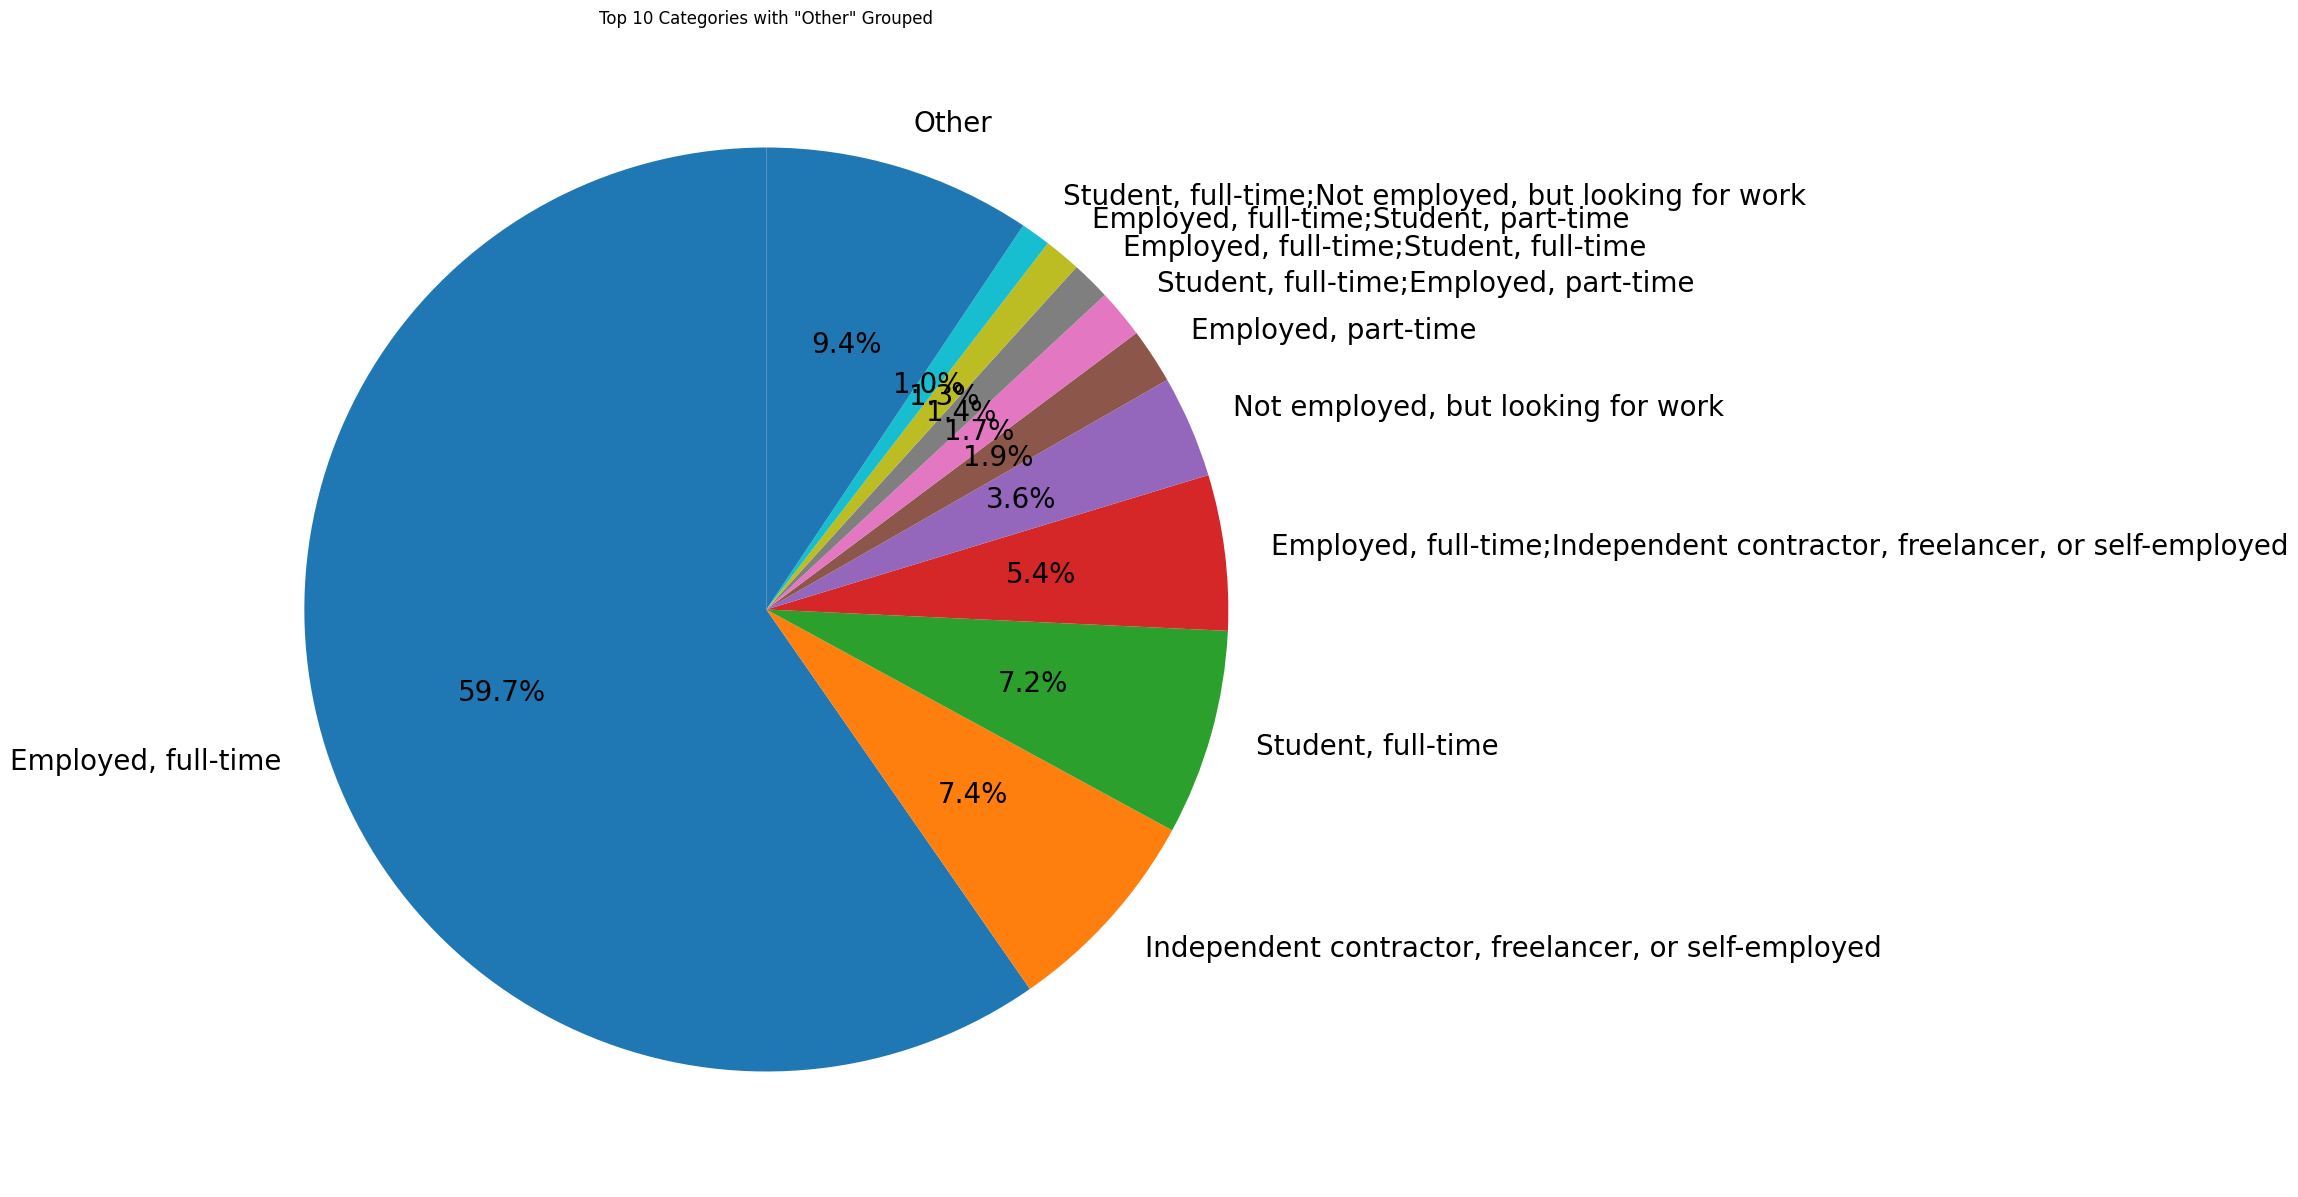

In [33]:
# 1. Get the frequency counts of your column (e.g., 'Employment')
counts = df['Employment'].value_counts()

# 2. Extract the top 10 categories
top_10 = counts.head(10)

# 3. Sum everything from index 10 onwards into an 'Other' category
other_sum = counts.iloc[10:].sum()

# 4. Combine them into a new series for plotting
# Using pd.concat to merge the top 10 and the 'Other' series
plot_data = pd.concat([top_10, pd.Series({'Other': other_sum})])

# 5. Plot the pie chart
plt.figure(figsize=(20, 15))
plot_data.plot(kind='pie', autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})

plt.title('Top 10 Categories with "Other" Grouped')
plt.ylabel('')  # Removes the default column label for a cleaner look
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
